In [2]:
# Support for maths
import numpy as np
import os
# Plotting tools
from matplotlib import pyplot as plt
# we use the following for plotting figures in jupyter
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# GPy: Gaussian processes library
import GPy

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse

# import optunity
# import optunity.metrics
import time

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
Y = pd.read_csv("vvr_dataset_Matern32_06-18-25.csv")[['Kc_best', 'Ki_best', 'Kd_best']]
X = pd.read_csv('vvr_dataset_Matern32_06-18-25.csv')[['Vdot_Vr']].values

Y_kp = Y[['Kc_best']].values
Y_ki = Y[['Ki_best']].values
Y_kd = Y[['Kd_best']].values

# Y1 = pd.read_csv("dataset_cleaned_plustestpoint.csv")[['Kc_best', 'Ki_best', 'Kd_best']]
# X1 = pd.read_csv('dataset_cleaned_plustestpoint.csv')[['Ca_in', 'Ti_in', 'Vdot_Vr', 'Qk_dot']].values

# # Y1 = pd.read_csv("../bo_dataset_4_linux_fixed.csv")[['Kc_best', 'Ki_best', 'Kd_best']]
# # X1 = pd.read_csv('../bo_dataset_4_linux_fixed.csv')[[ 'Ca_in', 'Ti_in', 'Vdot_Vr', 'Qk_dot']].values

# Y1_kp = Y1[['Kc_best']].values
# Y1_ki = Y1[['Ki_best']].values
# Y1_kd = Y1[['Kd_best']].values

# Xnew = pd.read_csv('../two_tanks/bo_tt_testset_FIXED_04-28-25.csv')[['Cai', 'F', 'Cac', 'Fc']].values
# Ynew = pd.read_csv('../two_tanks/bo_tt_testset_FIXED_04-28-25.csv')[['Kc_best', 'Ki_best', 'Kd_best']].values

# Normalize the outputs (optional but helpful when scales differ)
scaler = StandardScaler()
df_corr = pd.DataFrame(scaler.fit_transform(Y), columns=['Kc_best', 'Ki_best', 'Kd_best'])
# df1_corr = pd.DataFrame(scaler.fit_transform(Y1), columns=['Kc_best', 'Ki_best', 'Kd_best'])

df_corr

,Kc_best,Ki_best,Kd_best
0,0.263595,-1.578244,1.053020
1,-1.641056,-1.749950,-1.242535
2,2.216069,0.091955,2.096781
3,-0.547526,-0.666498,-0.450483
4,0.591576,-0.116997,0.632503
5,-0.259141,-0.147717,-0.229078
6,-0.336127,0.044000,-0.407430
7,0.479513,0.493324,0.474181
8,0.622722,1.072879,0.265810
9,-0.019028,1.661054,-0.632877


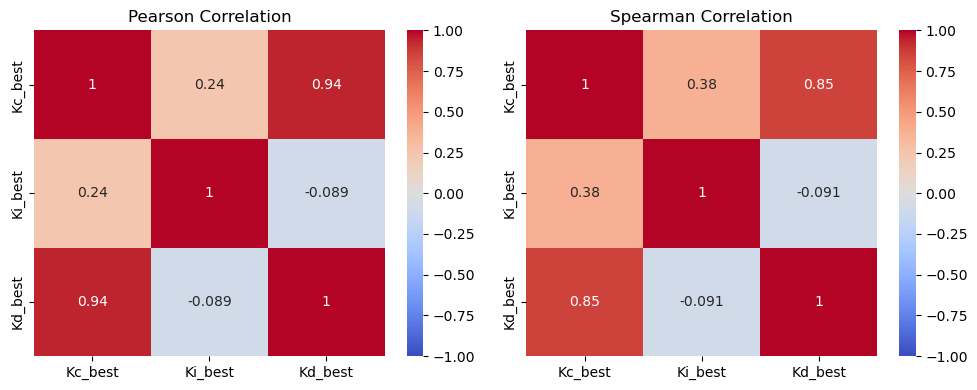

In [4]:
# Compute Pearson correlation matrix
pearson_corr = df_corr.corr(method='pearson')

# Compute Spearman correlation matrix
spearman_corr = df_corr.corr(method='spearman')

# Display correlation heatmaps
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation')

plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation')

plt.tight_layout()
plt.show()

In [10]:
# Initialize kernel and model
kp_kernel = GPy.kern.Exponential(input_dim=X.shape[1]) # No need for ARD with 1D input
kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
ki_kernel = GPy.kern.Exponential(input_dim=X.shape[1])
ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
kd_kernel = GPy.kern.Exponential(input_dim=X.shape[1])
kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)

# Set Gaussian Noise
kp_noise_var = 0.01
ki_noise_var = 0.01
kd_noise_var = 0.01

# Set parameter on model
kp_model.Gaussian_noise.variance = kp_noise_var
ki_model.Gaussian_noise.variance = ki_noise_var
kd_model.Gaussian_noise.variance = kd_noise_var

kp_model.Gaussian_noise.variance.fix()
ki_model.Gaussian_noise.variance.fix()
kd_model.Gaussian_noise.variance.fix()

# Optimize the model
kp_model.optimize_restarts(5, robust=True, messages=False)
ki_model.optimize_restarts(5, robust=True, messages=False)
kd_model.optimize_restarts(5, robust=True, messages=False)

print(kp_model)
print(ki_model)
print(kd_model)

Optimization restart 1/5, f = 61.22108477474913
Optimization restart 2/5, f = 61.22108476676008
Optimization restart 3/5, f = 61.22108479508653
Optimization restart 4/5, f = 61.22108787419693
Optimization restart 5/5, f = 61.2210847666915
Optimization restart 1/5, f = 63.015831102576044
Optimization restart 2/5, f = 73.00118431204571
Optimization restart 3/5, f = 63.014802826346795
Optimization restart 4/5, f = 63.01489525527751
Optimization restart 5/5, f = 63.01480006272203
Optimization restart 1/5, f = 16.20019995678511
Optimization restart 2/5, f = 16.200199966425615
Optimization restart 3/5, f = 16.200199958779944
Optimization restart 4/5, f = 16.200199954614646
Optimization restart 5/5, f = 16.20019996195643

Name : GP regression
Objective : 61.2210847666915
Number of Parameters : 3
Number of Optimization Parameters : 2
Updates : True
Parameters:
  GP_regression.           |               value  |  constraints  |  priors
  Exponential.variance     |    68491.6094955659  |      +v

In [42]:
from scipy.integrate import odeint

def get_ss(Cain, Tin, Vdot_Vr, Qkdot):
    # Simulation time
    num_sec = 5
    num_hours = 2
    t = np.linspace(0,num_hours,int(num_hours*60*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # Steady State conditions
    Ca_ss = 0
    Cb_ss = 0
    Tr_ss = 0
    Tk_ss = 0

    x0 = np.empty(4)
    x0[0] = Ca_ss
    x0[1] = Cb_ss
    x0[2] = Tr_ss
    x0[3] = Tk_ss

    u0 = np.ones(len(t))*Vdot_Vr
    u1 = np.ones(len(t))*Qkdot

    # Vectors for state variables
    Ca = np.zeros(len(t))
    Cb = np.zeros(len(t))
    Tr = np.zeros(len(t))
    Tk = np.zeros(len(t))

    # Manipulated variable conditions
    Cai = np.ones(len(t)) * Cain # mol/m3
    Ti = np.ones(len(t)) * Tin # Celsius

    # sp = np.ones(len(t)) * 1.09

    for i in range(len(t)-1):
        ts = [t[i],t[i+1]]
        y = odeint(vdv,x0,ts,args=(u0[i],u1[i],Cai[i],Ti[i]))
        Ca[i+1] = y[-1][0]
        Cb[i+1] = y[-1][1]
        Tr[i+1] = y[-1][2]
        Tk[i+1] = y[-1][3]
        x0[0] = Ca[i+1]
        x0[1] = Cb[i+1]
        x0[2] = Tr[i+1]
        x0[3] = Tk[i+1]
    
    lastCa = Ca[-1]
    lastCb = Cb[-1]
    lastTr = Tr[-1]
    lastTk = Tk[-1]

#     print("last Ca:", Ca[-1])
#     print("last Cb:", Cb[-1])
#     print("last Tr:", Tr[-1])
#     print("last Tk:", Tk[-1])
    
    return(lastCa, lastCb, lastTr, lastTk)

def test_exp(Kp, Ki, Kd, Ca_dt, Cb_dt, Tr_dt, Tk_dt, Vdot_Vr_dt, vstepsize, spstepsize, 
             kpm=None, kim=None, kdm=None, toplot = False):
    # Simulation time
    num_sec = 5
    num_hours = 7
    t = np.linspace(0,num_hours,round(num_hours*60*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # Steady State conditions
    Ca_ss = Ca_dt
    Cb_ss = Cb_dt
    Tr_ss = Tr_dt
    Tk_ss = Tk_dt
    
    print('Ca_ss:', Ca_ss)
    print('Cb_ss:', Cb_ss)
    print('Tr_ss:', Tr_ss)
    print('Tk_ss:', Tk_ss)

    Vdot_Vr = Vdot_Vr_dt # 1/hr
    Qkdot = -4000 # kJ/hr
    
    print('Vdot_Vr:', Vdot_Vr)
    print('Qkdot:', Qkdot)
    
    # Manipulated variable conditions
    Cai = np.ones(len(t)) * 5100 # mol/m3
#     Cai[1*720:] = Cai_dt + 200
#     Cai[4*720:] = Cai_dt - 100
    
    Ti = np.ones(len(t)) * 105 # Celsius
#     Ti[2*720:] = Ti_dt + 5
#     Ti[5*720:] = Ti_dt - 2

    # Declare variables to be passed to function for evaluation at each timestep
    xC = np.empty(4)
    xC[0] = Ca_ss
    xC[1] = Cb_ss
    xC[2] = Tr_ss
    xC[3] = Tk_ss
    
    x0 = np.empty(4)
    x0[0] = Ca_ss
    x0[1] = Cb_ss
    x0[2] = Tr_ss
    x0[3] = Tk_ss
    
#     x1 = np.empty(4)
#     x1[0] = Ca_ss
#     x1[1] = Cb_ss
#     x1[2] = Tr_ss
#     x1[3] = Tk_ss

    # Declare manipulated variables
    u0_C = np.ones(len(t))*Vdot_Vr
    u0_C[1*720:] = Vdot_Vr + vstepsize
    u0_C[3*720:] = Vdot_Vr - vstepsize
    u0_C[5*720:] = Vdot_Vr
    
#     u0_0 = np.ones(len(t))*Vdot_Vr
#     u0_0[3*720:] = Vdot_Vr + 2
#     u0_0[6*720:] = Vdot_Vr - 2
    
#     u0_0 = np.ones(len(t))*Vdot_Vr
#     u0_0[3*720:] = Vdot_Vr + 2
#     u0_0[6*720:] = Vdot_Vr - 2
    
    u1_C = np.ones(len(t))*Qkdot
    u1_0 = np.ones(len(t))*Qkdot
#     u1_1 = np.ones(len(t))*Qkdot

    # Vectors for state variables
    CaC = np.ones(len(t)) * Ca_ss
    CbC = np.ones(len(t)) * Cb_ss
    TrC = np.ones(len(t)) * Tr_ss
    TkC = np.ones(len(t)) * Tk_ss
    
    Ca0 = np.ones(len(t)) * Ca_ss
    Cb0 = np.ones(len(t)) * Cb_ss
    Tr0 = np.ones(len(t)) * Tr_ss
    Tk0 = np.ones(len(t)) * Tk_ss
    
#     Ca1 = np.ones(len(t)) * Ca_ss
#     Cb1 = np.ones(len(t)) * Cb_ss
#     Tr1 = np.ones(len(t)) * Tr_ss
#     Tk1 = np.ones(len(t)) * Tk_ss

    # Declare setpionts for both doublet tests
    spC = np.ones(len(t)) * Cb_ss
    spC[round(2*60*60/num_sec):] = Cb_ss + spstepsize
    spC[round(4*60*60/num_sec):] = Cb_ss - spstepsize
    spC[round(6*60*60/num_sec):] = Cb_ss
    
    # Track error for testing purposes
    errorC = np.zeros(len(t))
    error0 = np.zeros(len(t))
#     error1 = np.zeros(len(t))
    
    Kp_arr0 = np.zeros(len(t))
    Ki_arr0 = np.zeros(len(t))
    Kd_arr0 = np.zeros(len(t))
    
    Kp_arr0[0] = Kp
    Ki_arr0[0] = Ki
    Kd_arr0[0] = Kd
    
#     Kp_arr1 = np.zeros(len(t))
#     Ki_arr1 = np.zeros(len(t))
#     Kd_arr1 = np.zeros(len(t))
    
#     Kp_arr1[0] = Kp
#     Ki_arr1[0] = Ki
#     Kd_arr1[0] = Kd
    
#     # Set up PID controllers
#     Kpn = Kp*(10**kc_oom)
#     Kin = Ki*(10**ki_oom)
#     Kdn = Kd*(10**kd_oom)
    
#     umin = -8500
#     umax = 0
    umin = -8000
    umax = -50
    u_bias = Qkdot
    
    Kp_pidC = Kp
    Ki_pidC = Ki
    Kd_pidC = Kd
    
    ### From SS init, here are best parameters: 282.15110823, 964.01584358, 4.62714975
    # pid = PID(Kp,Ki,Kd,sample_time=None,output_limits=(umin,umax),meas_int=5,integral_timescale=1)
    pidC = PID(Kp_pidC,Ki_pidC,Kd_pidC,sample_time=None,output_limits=(umin-u_bias,umax-u_bias),meas_int=num_sec,integral_timescale=num_hours)
    pid0 = PID(Kp,Ki,Kd,sample_time=None,output_limits=(umin-u_bias,umax-u_bias),meas_int=num_sec,integral_timescale=num_hours)
    # pid1 = PID(Kp,Ki,Kd,sample_time=None,output_limits=(umin-u_bias,umax-u_bias),meas_int=num_sec,integral_timescale=num_hours)

    for i in range(len(t)-1):
        # Update setpoint and controller parameters for each PID controller
        pidC.setpoint = spC[i]
        pid0.setpoint = spC[i]
        # pid1.setpoint = spC[i]
        
#         tempC = np.array([[Cai[i], Ti[i], u0_C[i], u1_C[i]]])
        temp0 = np.array([[u0_C[i]]])
#         temp1 = np.array([[Cai[i], Ti[i], u0_C[i], u1_1[i]]])
        
        Kp0, Kp0var = kpm.predict(temp0)
        pid0.Kp = Kp0[0][0]
        Ki0, Ki0var = kim.predict(temp0)
        pid0.Ki = Ki0[0][0]
        Kd0, Kd0var = kdm.predict(temp0)
        pid0.Kd = Kd0[0][0]
        
        Kp_arr0[i] = Kp0[0][0]
        Ki_arr0[i] = Ki0[0][0]
        Kd_arr0[i] = Kd0[0][0]
        
#         Kp1, Kp1var = kp1_model.predict(temp1)
#         pid1.Kp = Kp1[0][0]
#         Ki1, Ki1var = ki1_model.predict(temp1)
#         pid1.Ki = Ki1[0][0]
#         Kd1, Kd1var = kd1_model.predict(temp1)
#         pid1.Kd = Kd1[0][0]
        
#         Kp_arr1[i] = Kp1[0][0]
#         Ki_arr1[i] = Ki1[0][0]
#         Kd_arr1[i] = Kd1[0][0]
        
        # Get next control action
        u1_C[i+1] = pidC(CbC[i], t[i+1]-t[i]) + u_bias
        u1_0[i+1] = pid0(Cb0[i], t[i+1]-t[i]) + u_bias
#         u1_1[i+1] = pid1(Cb1[i], t[i+1]-t[i]) + u_bias
        
        # Declare time interval
        ts = [t[i],t[i+1]]
        
        # Get next state based on control action and current state
        ### CHANGE U0 IF YOU WANT TO DO MIMO OR MISO CONTROL
        yC = odeint(vdv,xC,ts,args=(u0_C[i],u1_C[i],Cai[i],Ti[i]))
        y0 = odeint(vdv,x0,ts,args=(u0_C[i],u1_0[i],Cai[i],Ti[i]))
#         y1 = odeint(vdv,x1,ts,args=(u0_C[i],u1_1[i],Cai[i],Ti[i]))
        
        # Update vectors data storage
        CaC[i+1] = yC[-1][0]
        CbC[i+1] = yC[-1][1]
        TrC[i+1] = yC[-1][2]
        TkC[i+1] = yC[-1][3]
        xC[0] = CaC[i+1]
        xC[1] = CbC[i+1]
        xC[2] = TrC[i+1]
        xC[3] = TkC[i+1]
        
        Ca0[i+1] = y0[-1][0]
        Cb0[i+1] = y0[-1][1]
        Tr0[i+1] = y0[-1][2]
        Tk0[i+1] = y0[-1][3]
        x0[0] = Ca0[i+1]
        x0[1] = Cb0[i+1]
        x0[2] = Tr0[i+1]
        x0[3] = Tk0[i+1]
        
#         Ca1[i+1] = y1[-1][0]
#         Cb1[i+1] = y1[-1][1]
#         Tr1[i+1] = y1[-1][2]
#         Tk1[i+1] = y1[-1][3]
#         x1[0] = Ca1[i+1]
#         x1[1] = Cb1[i+1]
#         x1[2] = Tr1[i+1]
#         x1[3] = Tk1[i+1]
        
        # Track error
        errorC[i] = spC[i] - CbC[i]
        error0[i] = spC[i] - Cb0[i]
#         error1[i] = spC[i] - Cb1[i]
        
#         PID0_prop_err[i] = pid0.components[0]
#         PID0_int_err[i] = pid0.components[1]
#         PID0_der_err[i] = pid0.components[2]

    ### Need to deal with the final conditions
    temp_0 = np.array([[u0_C[len(t)-1]]])
    Kp0_0, Kp0var = kpm.predict(temp_0)
    Kp_arr0[-1] = Kp0_0[0][0]
    Ki0_0, Ki0var = kim.predict(temp_0)
    Ki_arr0[-1] = Ki0_0[0][0]
    Kd0_0, Kd0var = kdm.predict(temp_0)
    Kd_arr0[-1] = Kd0_0[0][0]
    
#     temp_1 = np.array([[Cai[len(t)-1], Ti[len(t)-1], u0_C[len(t)-1], u1_1[len(t)-1]]])
#     Kp0_1, Kp0var = kp1_model.predict(temp_1)
#     Kp_arr1[-1] = Kp0_1[0][0]
#     Ki0_1, Ki0var = ki1_model.predict(temp_1)
#     Ki_arr1[-1] = Ki0_1[0][0]
#     Kd0_1, Kd0var = kd1_model.predict(temp_1)
#     Kd_arr1[-1] = Kd0_1[0][0]

    if toplot:
        plt.figure(figsize=(10,35))
        plt.subplot(15,1,1)
        plt.plot(t,Cai,'b',linewidth=3)
        plt.ylabel('Ca initial (mol/m3)')
        plt.legend(['Cai'],loc='best')

        plt.subplot(15,1,2)
        plt.plot(t,Ti,'r',linewidth=3)
        plt.ylabel('Temperature initial (C)')
        plt.legend(['Ti'],loc='best')

        plt.subplot(15,1,3)
        plt.plot(t,u0_C,'g',linewidth=3)
        plt.ylabel('VVr')
        plt.legend(['Vdot_Vr'],loc='best')

        plt.subplot(15,1,4)
        plt.plot(t,CaC,'b',linewidth=3)
        plt.ylabel('CaC (mol/m3)')
        plt.legend(['Control Reactor Ca'],loc='best')

        plt.subplot(15,1,5)
        plt.plot(t,CbC,'b',linewidth=3)
        plt.plot(t,spC,'k--',linewidth=3)
        plt.ylabel('CbC (mol/m3)')
        plt.legend(['Control Reactor Cb, Setpoint'],loc='best')

        plt.subplot(15,1,6)
        plt.plot(t,TrC,'r',linewidth=3)
        plt.ylabel('Control Reactor temperature (C))')
        plt.legend(['TrC'],loc='best')

        plt.subplot(15,1,7)
        plt.plot(t,TkC,'r',linewidth=3)
        plt.ylabel('Control Coolant temperature (C)')
        plt.legend(['TkC'],loc='best')

        plt.subplot(15,1,8)
        plt.plot(t,u1_C,'g',linewidth=3)
        plt.ylabel('Qkdot Control Reactor (kJ/hr)')
        plt.legend(['Qkdot0'],loc='best')    

        plt.subplot(15,1,9)
        plt.plot(t,Ca0,'b',linewidth=3)
        plt.ylabel('Ca0 (mol/m3)')
        plt.legend(['Reactor 0 Ca'],loc='best')

        plt.subplot(15,1,10)
        plt.plot(t,Cb0,'b',linewidth=3)
        plt.plot(t,spC,'k--',linewidth=3)
        plt.ylabel('Cb0 (mol/m3)')
        plt.legend(['Reactor 0 Cb, Setpoint'],loc='best')

        plt.subplot(15,1,11)
        plt.plot(t,Tr0,'r',linewidth=3)
        plt.ylabel('Reactor 0 temperature (C))')
        plt.legend(['Tr0'],loc='best')

        plt.subplot(15,1,12)
        plt.plot(t,Tk0,'r',linewidth=3)
        plt.ylabel('Coolant 0 temperature (C)')
        plt.legend(['Tk0'],loc='best')

        plt.subplot(15,1,13)
        plt.plot(t,u1_0,'g',linewidth=3)
        plt.ylabel('Qkdot Reactor 0 (kJ/hr)')
        plt.legend(['Qkdot0'],loc='best')

    #     plt.subplot(21,1,14)
    #     plt.plot(t,Ca1,'b',linewidth=3)
    #     plt.ylabel('Ca1 (mol/m3)')
    #     plt.legend(['Reactor 1 Ca'],loc='best')

    #     plt.subplot(21,1,15)
    #     plt.plot(t,Cb1,'b',linewidth=3)
    #     plt.plot(t,spC,'k--',linewidth=3)
    #     plt.ylabel('Cb1 (mol/m3)')
    #     plt.legend(['Reactor 1 Cb', 'Setpoint'],loc='best')

    #     plt.subplot(21,1,16)
    #     plt.plot(t,Tr1,'r',linewidth=3)
    #     plt.ylabel('Reactor 1 temperature (C))')
    #     plt.legend(['Tr1'],loc='best')

    #     plt.subplot(21,1,17)
    #     plt.plot(t,Tk1,'r',linewidth=3)
    #     plt.ylabel('Coolant 1 temperature (C)')
    #     plt.legend(['Tk1'],loc='best')

    #     plt.subplot(21,1,18)
    #     plt.plot(t,u1_1,'g',linewidth=3)
    #     plt.ylabel('Qkdot Reactor 1 (kJ/hr)')
    #     plt.legend(['Qkdot1'],loc='best')

        plt.subplot(15,1,14)
        plt.plot(t,errorC,'y',linewidth=3)
        plt.ylabel('Error Control reactor')
        plt.legend(['errorC'],loc='best')

        plt.subplot(15,1,15)
        plt.plot(t,error0,'y',linewidth=3)
        plt.ylabel('Error reactor 0')
        plt.legend(['error0'],loc='best')

    #     plt.subplot(21,1,21)
    #     plt.plot(t,error1,'y',linewidth=3)
    #     plt.ylabel('Error reactor 1')
    #     plt.legend(['error1'],loc='best')

        plt.show()

        plt.figure(figsize=(10,6))
        plt.subplot(3,1,1)
        plt.plot(t,Kp_arr0,'g',linewidth=3)
        plt.ylabel('Kp0')
        plt.legend(['Kp_0'],loc='best')

        plt.subplot(3,1,2)
        plt.plot(t,Ki_arr0,'g',linewidth=3)
        plt.ylabel('Ki0')
        plt.legend(['Ki_0'],loc='best')

        plt.subplot(3,1,3)
        plt.plot(t,Kd_arr0,'g',linewidth=3)
        plt.ylabel('Kd0')
        plt.legend(['Kd_0'],loc='best')
    
    #     plt.subplot(6,1,4)
    #     plt.plot(t,Kp_arr1,'g',linewidth=3)
    #     plt.ylabel('Kp1')
    #     plt.legend(['Kp_1'],loc='best')

    #     plt.subplot(6,1,5)
    #     plt.plot(t,Ki_arr1,'g',linewidth=3)
    #     plt.ylabel('Ki1')
    #     plt.legend(['Ki_1'],loc='best')

    #     plt.subplot(6,1,6)
    #     plt.plot(t,Kd_arr1,'g',linewidth=3)
    #     plt.ylabel('Kd1')
    #     plt.legend(['Kd_1'],loc='best')

    #     plt.subplot(6,1,4)
    #     plt.plot(t,PID1_prop_err,'b',linewidth=3)
    #     plt.ylabel('Error from Kp1')
    #     plt.legend(['Kp_err_1'],loc='best')

    #     plt.subplot(6,1,5)
    #     plt.plot(t,PID1_int_err,'b',linewidth=3)
    #     plt.ylabel('Error from Ki1')
    #     plt.legend(['Ki_err_1'],loc='best')

    #     plt.subplot(6,1,6)
    #     plt.plot(t,PID1_der_err,'b',linewidth=3)
    #     plt.ylabel('Error from Kd1')
    #     plt.legend(['Kd_err_1'],loc='best')
    #     plt.xlabel('Time (hr)')
    
    print('sum errorC:', sum(errorC))
    print('sum error0:', sum(error0))
#     print('sum error1:', sum(error1))
    print('sum abs errorC:', sum(abs(errorC)))
    print('sum abs error0:', sum(abs(error0)))
#     print('sum abs error1:', sum(abs(error1)))

#     print("last Ca:", Ca[-1])
#     print("last Cb:", Cb[-1])
#     print("last Tr:", Tr[-1])
#     print("last Tk:", Tk[-1])

In [43]:
Cai_te, Ti_te, VVr_te, Qk_te = 5100, 105, 20, -4000
Ca_ss, Cb_ss, Tr_ss, Tk_ss = get_ss(Cai_te, Ti_te, VVr_te, Qk_te)
Kpinit, Kpvinit = kp_model.predict(np.array([[VVr_te]]))
Kp_te = Kpinit[0][0]
Kiinit, Kivinit = ki_model.predict(np.array([[VVr_te]]))
Ki_te = Kiinit[0][0]
Kdinit, Kdvinit = kd_model.predict(np.array([[VVr_te]]))
Kd_te = Kdinit[0][0]

print("Kp:", Kp_te)
print("Ki:", Ki_te)
print("Kd:", Kd_te)

test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 1, 1, kp_model, ki_model, kd_model)

Kp: 265.95175828251604
Ki: 981.2036089037847
Kd: 4.288008657040056
Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: -0.04172099432980758
sum error0: -1.996197577485873
sum abs errorC: 856.2781561728136
sum abs error0: 856.5413990737754


Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000


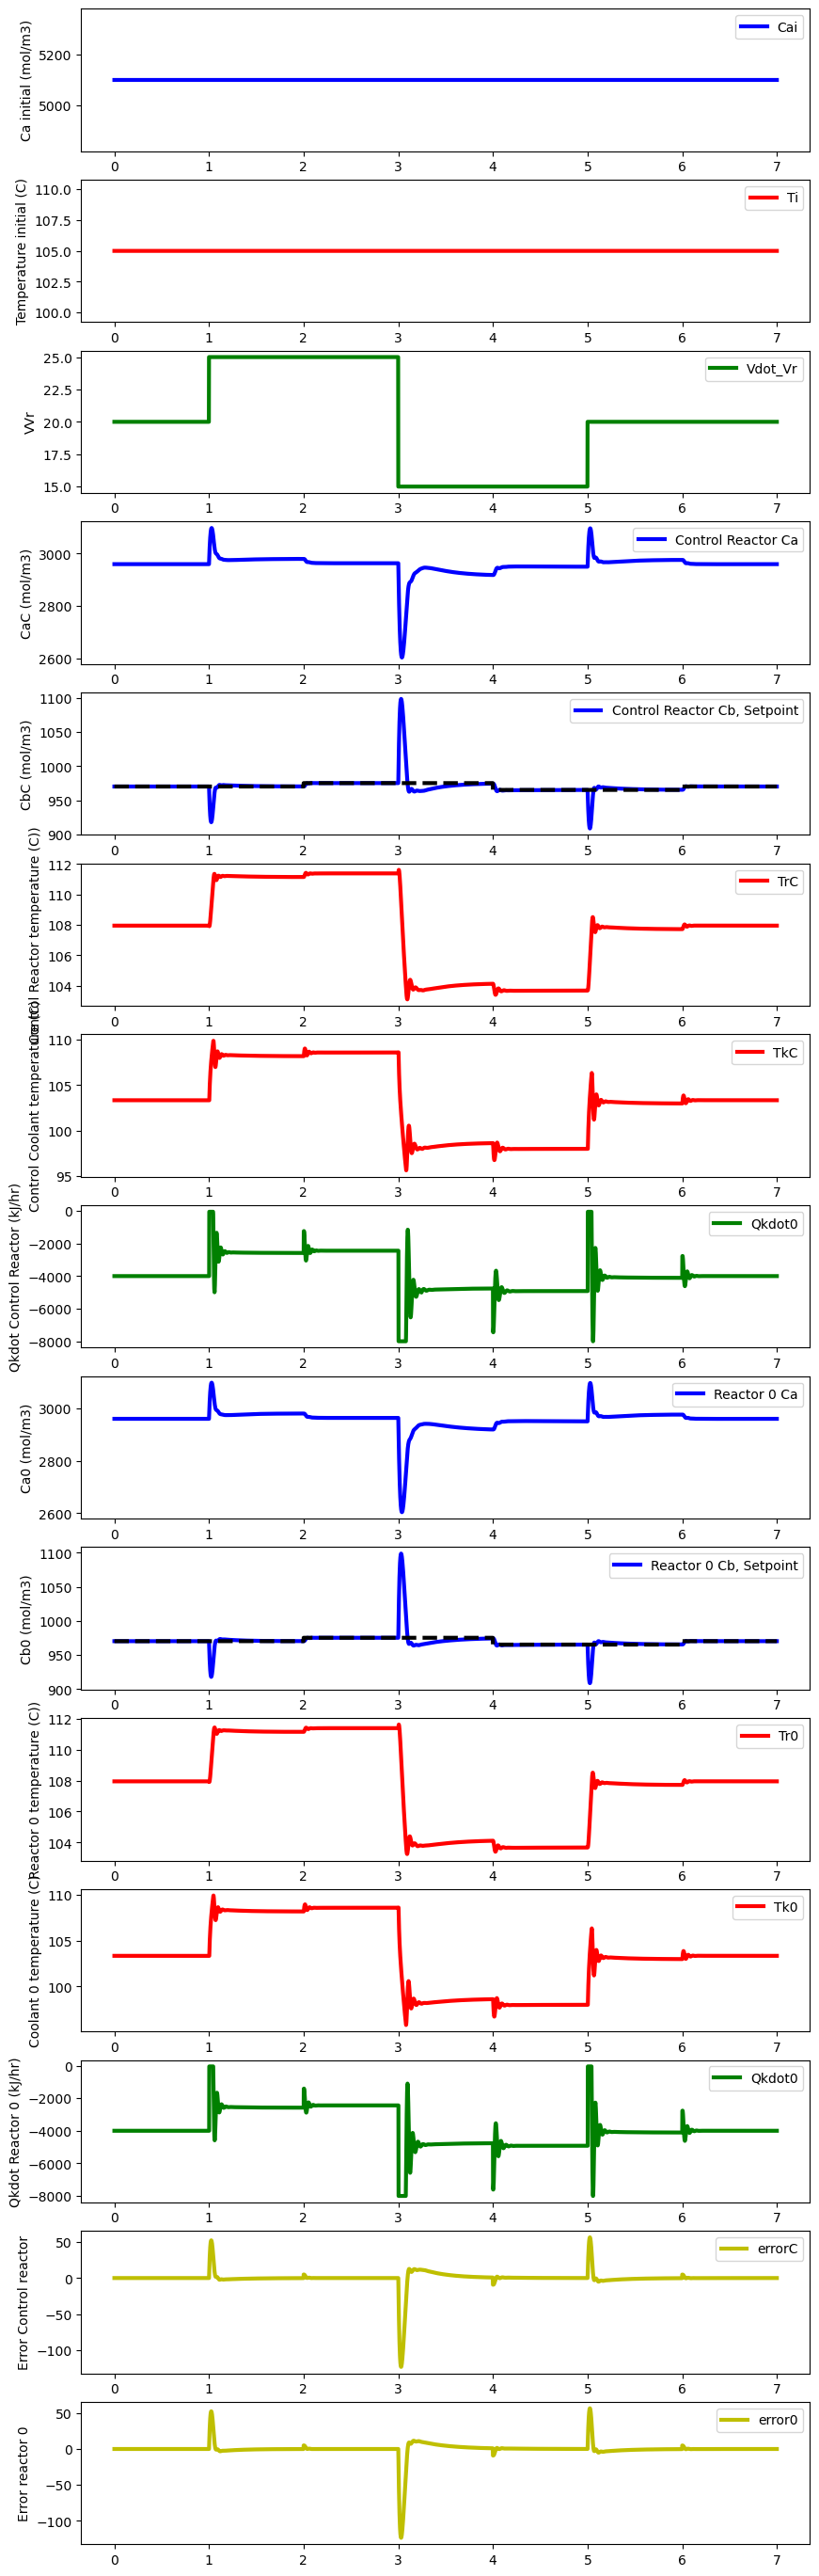

sum errorC: 0.8945259545755562
sum error0: -310.742396114454
sum abs errorC: 13589.735772681683
sum abs error0: 13369.14559441901


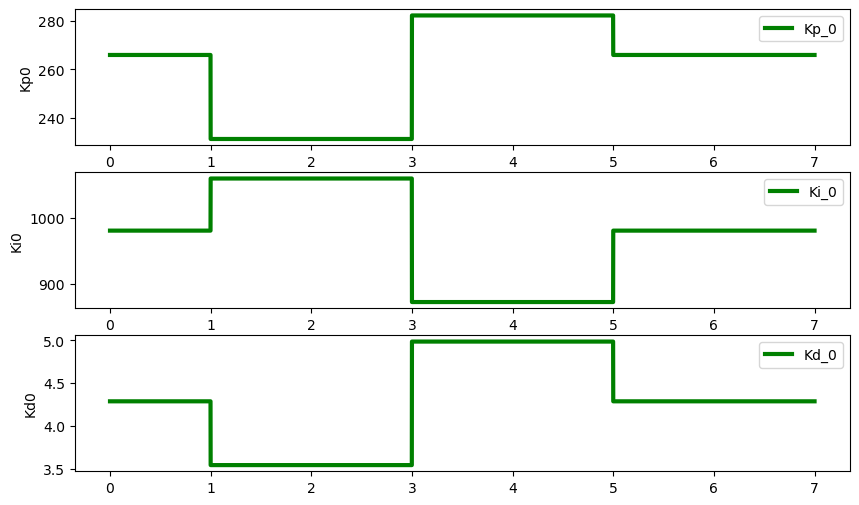

In [48]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 5, 5, kp_model, ki_model, kd_model, toplot=True)

In [45]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 3, 3, kp_model, ki_model, kd_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: 0.22857105584489545
sum error0: -34.32972269937136
sum abs errorC: 5240.015489943391
sum abs error0: 5261.791891227464


In [46]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 2.5, 2.5, kp_model, ki_model, kd_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: 0.12277795431953109
sum error0: -44.64618780809019
sum abs errorC: 3685.4240691621644
sum abs error0: 3690.1436828559163


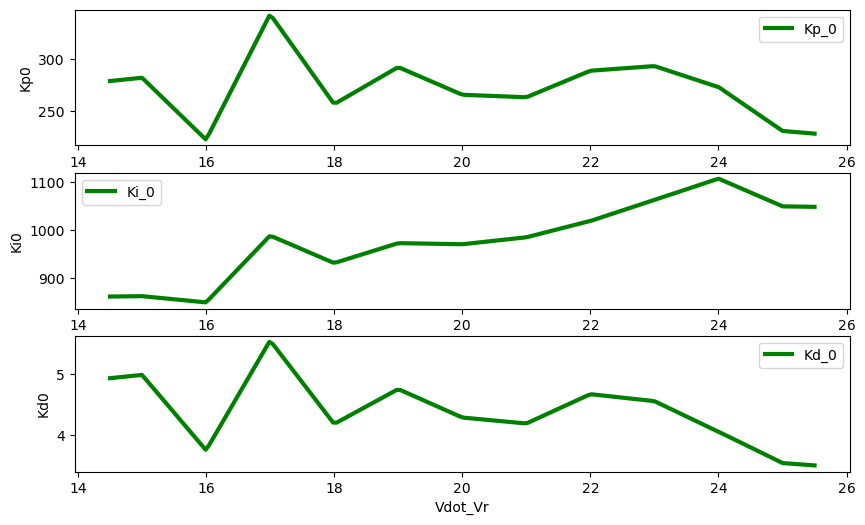

In [30]:
xvis = np.linspace(14.5, 25.5, 200)[:, None]
kp_vis, kp_Covvis = kp_model.predict_noiseless(xvis, full_cov=True)
ki_vis, ki_Covvis = ki_model.predict_noiseless(xvis, full_cov=True)
kd_vis, kd_Covvis = kd_model.predict_noiseless(xvis, full_cov=True)

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.plot(xvis,kp_vis,'g',linewidth=3)
plt.ylabel('Kp0')
plt.legend(['Kp_0'],loc='best')

plt.subplot(3,1,2)
plt.plot(xvis,ki_vis,'g',linewidth=3)
plt.ylabel('Ki0')
plt.legend(['Ki_0'],loc='best')

plt.subplot(3,1,3)
plt.plot(xvis,kd_vis,'g',linewidth=3)
plt.ylabel('Kd0')
plt.xlabel("Vdot_Vr")
plt.legend(['Kd_0'],loc='best')

In [33]:
# Initialize kernel and model
kp_m32_kernel = GPy.kern.Matern32(input_dim=X.shape[1]) # No need for ARD with 1D input
kp_m32_model = GPy.models.GPRegression(X, Y_kp, kp_m32_kernel)
ki_m32_kernel = GPy.kern.Matern32(input_dim=X.shape[1])
ki_m32_model = GPy.models.GPRegression(X, Y_ki, ki_m32_kernel)
kd_m32_kernel = GPy.kern.Matern32(input_dim=X.shape[1])
kd_m32_model = GPy.models.GPRegression(X, Y_kd, kd_m32_kernel)

# Set Gaussian Noise
kp_m32_noise_var = 0.01
ki_m32_noise_var = 0.01
kd_m32_noise_var = 0.01

# Set parameter on model
kp_m32_model.Gaussian_noise.variance = kp_noise_var
ki_m32_model.Gaussian_noise.variance = ki_noise_var
kd_m32_model.Gaussian_noise.variance = kd_noise_var

kp_m32_model.Gaussian_noise.variance.fix()
ki_m32_model.Gaussian_noise.variance.fix()
kd_m32_model.Gaussian_noise.variance.fix()

# Optimize the model
kp_m32_model.optimize_restarts(5, robust=True, messages=False)
ki_m32_model.optimize_restarts(5, robust=True, messages=False)
kd_m32_model.optimize_restarts(5, robust=True, messages=False)

print(kp_m32_model)
print(ki_m32_model)
print(kd_m32_model)

Optimization restart 1/5, f = 66.13372378525962
Optimization restart 2/5, f = 66.1337237851346
Optimization restart 3/5, f = 66.13372378507013
Optimization restart 4/5, f = 76.08111133445112
Optimization restart 5/5, f = 66.13372378491383
Optimization restart 1/5, f = 68.58414320981333
Optimization restart 2/5, f = 68.58414321006543
Optimization restart 3/5, f = 68.5841432095816
Optimization restart 4/5, f = 79.30680308646619
Optimization restart 5/5, f = 68.58414320959321
Optimization restart 1/5, f = 21.11439462596504
Optimization restart 2/5, f = 21.11439462578718
Optimization restart 3/5, f = 21.114394626668833
Optimization restart 4/5, f = 21.114394625675203
Optimization restart 5/5, f = 21.114394625692775

Name : GP regression
Objective : 66.13372378491383
Number of Parameters : 3
Number of Optimization Parameters : 2
Updates : True
Parameters:
  GP_regression.           |              value  |  constraints  |  priors
  Mat32.variance           |  54571.32558798888  |      +ve   

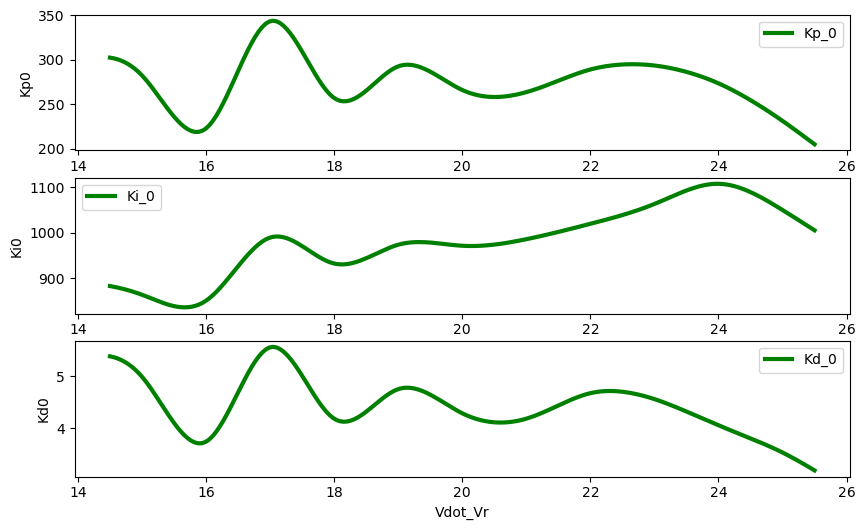

In [34]:
xvis = np.linspace(14.5, 25.5, 200)[:, None]
kp_m32_vis, kp_Covvis = kp_m32_model.predict_noiseless(xvis, full_cov=True)
ki_m32_vis, ki_Covvis = ki_m32_model.predict_noiseless(xvis, full_cov=True)
kd_m32_vis, kd_Covvis = kd_m32_model.predict_noiseless(xvis, full_cov=True)

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.plot(xvis,kp_m32_vis,'g',linewidth=3)
plt.ylabel('Kp0')
plt.legend(['Kp_0'],loc='best')

plt.subplot(3,1,2)
plt.plot(xvis,ki_m32_vis,'g',linewidth=3)
plt.ylabel('Ki0')
plt.legend(['Ki_0'],loc='best')

plt.subplot(3,1,3)
plt.plot(xvis,kd_m32_vis,'g',linewidth=3)
plt.ylabel('Kd0')
plt.xlabel("Vdot_Vr")
plt.legend(['Kd_0'],loc='best')

In [49]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 1, 1, kp_m32_model, ki_m32_model, kd_m32_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: -0.04172099432980758
sum error0: -2.046532172123648
sum abs errorC: 856.2781561728136
sum abs error0: 858.2312364387234


In [50]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 5, 5, kp_m32_model, ki_m32_model, kd_m32_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: 0.8945259545755562
sum error0: -317.58469272518164
sum abs errorC: 13589.735772681683
sum abs error0: 13328.18314746387


In [51]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 2, 3, kp_m32_model, ki_m32_model, kd_m32_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: 0.051913678179516864
sum error0: -53.151924596008826
sum abs errorC: 2494.981887648189
sum abs error0: 2449.624535643169


In [52]:
test_exp(Kp_te, Ki_te, Kd_te, Ca_ss, Cb_ss, Tr_ss, Tk_ss, VVr_te, 2.5, 2.5, kp_m32_model, ki_m32_model, kd_m32_model)

Ca_ss: 2959.786392576009
Cb_ss: 970.3282319472795
Tr_ss: 107.95043684859925
Tk_ss: 103.33618804741093
Vdot_Vr: 20
Qkdot: -4000
sum errorC: 0.12277795431953109
sum error0: -34.80566638070502
sum abs errorC: 3685.4240691621644
sum abs error0: 3687.057796094626


In [1]:
import time
import warnings
from collections import deque


def _clamp(value, limits):
    lower, upper = limits
    if value is None:
        return None
    elif upper is not None and value > upper:
        return upper
    elif lower is not None and value < lower:
        return lower
    return value

try:
    # get monotonic time to ensure that time deltas are always positive
    _current_time = time.monotonic
except AttributeError:
    # time.monotonic() not available (using python < 3.3), fallback to time.time()
    _current_time = time.time
    warnings.warn('time.monotonic() not available in python < 3.3, using time.time() as fallback')


class PID(object):
    """
    A simple PID controller. No fuss.
    """

    def __init__(self,
                 Kp=1.0, Ki=0.0, Kd=0.0,
                 setpoint=0,
                 sample_time=0.01,
                 meas_int=1,
                 output_limits=(None, None),
                 auto_mode=True,
                 proportional_on_measurement=False,
                 integral_timescale=0):
        """
        :param Kp: The value for the proportional gain Kp
        :param Ki: The value for the integral gain Ki
        :param Kd: The value for the derivative gain Kd
        :param setpoint: The initial setpoint that the PID will try to achieve
        :param sample_time: The time in seconds which the controller should wait before generating a new output value.
                            The PID works best when it is constantly called (eg. during a loop), but with a sample
                            time set so that the time difference between each update is (close to) constant. If set to
                            None, the PID will compute a new output value every time it is called.
        :param output_limits: The initial output limits to use, given as an iterable with 2 elements, for example:
                              (lower, upper). The output will never go below the lower limit or above the upper limit.
                              Either of the limits can also be set to None to have no limit in that direction. Setting
                              output limits also avoids integral windup, since the integral term will never be allowed
                              to grow outside of the limits.
        :param auto_mode: Whether the controller should be enabled (in auto mode) or not (in manual mode)
        :param proportional_on_measurement: Whether the proportional term should be calculated on the input directly
                                            rather than on the error (which is the traditional way). Using
                                            proportional-on-measurement avoids overshoot for some types of systems.
        """
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.setpoint = setpoint
        self.sample_time = sample_time

        self._min_output, self._max_output = output_limits
        self._auto_mode = auto_mode
        self.proportional_on_measurement = proportional_on_measurement
        
        self.integral_timescale = integral_timescale # Do in hours
        self.meas_int = meas_int # This will be in seconds
        
        # Declare list that will maintain a set timeframe of error terms to sum
        self.integral_terms = deque(maxlen=round(self.integral_timescale*60*60/self.meas_int))

        self.reset()

    def __call__(self, input_, dt=None):
        """
        Call the PID controller with *input_* and calculate and return a control output if sample_time seconds has
        passed since the last update. If no new output is calculated, return the previous output instead (or None if
        no value has been calculated yet).
        :param dt: If set, uses this value for timestep instead of real time. This can be used in simulations when
                   simulation time is different from real time.
        """
        if not self.auto_mode:
            return self._last_output

        now = _current_time()
        if dt is None:
            dt = now - self._last_time if now - self._last_time else 1e-16
        elif dt <= 0:
            raise ValueError("dt has nonpositive value {}. Must be positive.".format(dt))

        if self.sample_time is not None and dt < self.sample_time and self._last_output is not None:
            # only update every sample_time seconds
            return self._last_output

        # compute error terms
        error = self.setpoint - input_
        d_input = input_ - (self._last_input if self._last_input is not None else input_)

        # compute the proportional term
        if not self.proportional_on_measurement:
            # regular proportional-on-error, simply set the proportional term
            self._proportional = self.Kp * error
        else:
            # add the proportional error on measurement to error_sum
            self._proportional -= self.Kp * d_input

        # compute integral and derivative terms
        if self.integral_timescale == 0:
            self._integral += self.Ki * error * dt
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup
        # if interested in using a set timeframe for error integral, use this
        else:
            self.integral_terms.append(self.Ki * error * dt) # deque automatically discards oldest element when full
            self._integral = sum(self.integral_terms)
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup            

        self._derivative = -self.Kd * d_input / dt

        # compute final output
        output = self._proportional + self._integral + self._derivative
        output = _clamp(output, self.output_limits)

        # keep track of state
        self._last_output = output
        self._last_input = input_
        self._last_time = now

        return output

    @property
    def components(self):
        """
        The P-, I- and D-terms from the last computation as separate components as a tuple. Useful for visualizing
        what the controller is doing or when tuning hard-to-tune systems.
        """
        return self._proportional, self._integral, self._derivative

    @property
    def tunings(self):
        """The tunings used by the controller as a tuple: (Kp, Ki, Kd)"""
        return self.Kp, self.Ki, self.Kd

    @tunings.setter
    def tunings(self, tunings):
        """Setter for the PID tunings"""
        self.Kp, self.Ki, self.Kd = tunings

    @property
    def auto_mode(self):
        """Whether the controller is currently enabled (in auto mode) or not"""
        return self._auto_mode

    @auto_mode.setter
    def auto_mode(self, enabled):
        """Enable or disable the PID controller"""
        self.set_auto_mode(enabled)

    def set_auto_mode(self, enabled, last_output=None):
        """
        Enable or disable the PID controller, optionally setting the last output value.
        This is useful if some system has been manually controlled and if the PID should take over.
        In that case, pass the last output variable (the control variable) and it will be set as the starting
        I-term when the PID is set to auto mode.
        :param enabled: Whether auto mode should be enabled, True or False
        :param last_output: The last output, or the control variable, that the PID should start from
                            when going from manual mode to auto mode
        """
        if enabled and not self._auto_mode:
            # switching from manual mode to auto, reset
            self.reset()

            self._integral = (last_output if last_output is not None else 0)
            self._integral = _clamp(self._integral, self.output_limits)

        self._auto_mode = enabled

    @property
    def output_limits(self):
        """
        The current output limits as a 2-tuple: (lower, upper). See also the *output_limts* parameter in
        :meth:`PID.__init__`.
        """
        return self._min_output, self._max_output

    @output_limits.setter
    def output_limits(self, limits):
        """Setter for the output limits"""
        if limits is None:
            self._min_output, self._max_output = None, None
            return

        min_output, max_output = limits

        if None not in limits and max_output < min_output:
            raise ValueError('lower limit must be less than upper limit')

        self._min_output = min_output
        self._max_output = max_output

        self._integral = _clamp(self._integral, self.output_limits)
        self._last_output = _clamp(self._last_output, self.output_limits)

    def reset(self):
        """
        Reset the PID controller internals, setting each term to 0 as well as cleaning the integral,
        the last output and the last input (derivative calculation).
        """
        self._proportional = 0
        self._integral = 0
        self._derivative = 0

        self._last_time = _current_time()
        self._last_output = None
        self._last_input = None
        


# define Van de Vusse system model
def vdv(x,t,u0,u1,Cai,Ti):
    # Declare states from x vector
    Ca = x[0]      # Concentration of A exiting the tank, mol/m3
    Cb = x[1]      # Concentration of B exiting the tank, mol/m3
    Tr = x[2]      # Reactor temperature, K
    Tk = x[3]      # Coolant temperature, K
    
    # Declare control state from u vector
    Vdot_Vr = u0      # Volumetric flowrate divided by reactor volume, 1/hr
    Qkdot = u1      # Heat removal from reactor, kJ/hr
    
    
    # Uncertainties taken from Chen, Kremling, and Allgower, 1995
    # These uncertainties match Hajaya and Shaqarin, 2019, which I am using heavily for the model
    # Note that A -> B and B -> C share the same reaction parameters, k1 and E1
    
    # Collision rates
    k10 = 1.287 * 10**12      # hr^-1, +- 0.04 before exponential
    k20 = 9.043 * 10**6      # m^3/(molA*hr), +- 0.27 before exponential
    ### 10^9 is for L/(molA*hr).
    
    # Activation energies
    E1 = -9758.3      # K
    E2 = -8560.0      # K
                    
    # Reaction rate constants
    k1 = k10*np.exp(E1/(Tr+273.15))      # 
    k2 = k20*np.exp(E2/(Tr+273.15))      # 
    
    # Enthalpy of reaction for all three reactions
    delH_Rab = 4.2      # kJ/molA, +- 2.36 
    delH_Rbc = -11.0      #kJ/molB, +- 1.92
    delH_Rad = -41.85      #kJ/molA, +- 1.41
    
    # Heat capacity of liquid phase in reactor
    Cp = 3.01      # kJ/(kg*K)
    
    # Density of liquid phase
    rho = 934.2      # kg/m3, +- 0.4
    
    # Heat capacity of coolant
    Cpk = 2.0      # kJ/(kg*K), +- 0.05
    
    # Mass of coolant
    mk = 5.0      # kg
    
    # Volume of reactor
    Vr = 0.01      # m3
    
    # Surface area of cooling jacket
    Ar = 0.215      # m2
    
    # Heat transfer coefficient for cooling jacket
    kw = 4032      # kJ/(h*m2*K), +- 120
    
    # Derivatives
    # Calculate derivative of Ca
    dCadt = (Vdot_Vr)*(Cai-Ca) - k1*Ca - k2*(Ca**2)
    
    # Calculate derivative of Cb
    dCbdt = -Vdot_Vr*Cb + k1*(Ca-Cb)
    
    # Calculate derivative of reactor temperature
    dTrdt = (Vdot_Vr)*(Ti-Tr) - (1/(rho*Cp))*((k1*Ca*delH_Rab) \
                        + k1*Cb*delH_Rbc + k2*(Ca**2)*delH_Rad) + (kw*Ar/(rho*Cp*Vr))*(Tk-Tr)
    
    # Calculate derivative of coolant temperature
    dTkdt = (1/(mk*Cpk))*(Qkdot + kw*Ar*(Tr - Tk))
    
    # Return xdot:
    xdot = np.zeros(4)
    xdot[0] = dCadt
    xdot[1] = dCbdt
    xdot[2] = dTrdt
    xdot[3] = dTkdt
    return xdot

In [61]:
testing = np.linspace(0,20,21)
testing[5:15]

testing = np.ones(20)
testing[5:16] = np.linspace(5,15,len(testing[5:16]))
testing

array([ 1.,  1.,  1.,  1.,  1.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15.,  1.,  1.,  1.,  1.])